# 01_growth_curve_analysis

# Importações

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import graphviz
%matplotlib inline

# Importar funções dos scripts

In [2]:
import sys
import os
sys.path.append('/home/huguinho/Documents/GitHub/robust_nlme_analysis/scripts')
from models import approximate_nlme
from utils import detect_outliers, plot_individual_fits

# Funções para o modelo logístico

In [3]:
def logistic(X, beta, b=None):
    """Função logística de 3 parâmetros"""
    if b is None:
        b = np.zeros(3)
        
    t = X[:, 0]  # tempo
    beta_i = beta + b
    
    return beta_i[0] / (1 + np.exp(-(t - beta_i[1]) / beta_i[2]))


This code defines a function named `logistic` that implements the three-parameter version of the logistic function. The logistic function is commonly used to model binomial distributions and can also be applied in other scenarios where a nonlinear relationship is needed. The purpose of this function is to calculate the value of the logistic function based on the input parameters.

### Implementation Details

1. **Function Definition**: The `logistic` function accepts three parameters: `X` (input data, typically a two-dimensional array where each row represents a sample and each column represents a feature), `beta` (parameters of the logistic function, usually a one-dimensional array), and an optional parameter `b` (bias term, default is `None`).

2. **Handling Bias Term**: If the `b` parameter is `None`, it is initialized to a full-zero array of length 3. This means that if no bias term is provided, the function assumes the bias term to be 0.

3. **Parameter Adjustment**: The function adds `beta` and `b` to get the new parameter `beta_i`.

4. **Logistic Function Calculation**: The function calculates the value of the logistic function using the parameters in `beta_i`. The logistic function is defined as:
   \[
   f(t) = \frac{\beta_0}{1 + e^{-(t - \beta_1) / \beta_2}}
   \]
   where `t` is the time (or any independent variable), and `\beta_0`, `\beta_1`, and `\beta_2` are the parameters of the logistic function.

### Usage

This function can be used in various scenarios requiring nonlinear modeling, such as modeling gene expression data in bioinformatics or modeling population growth models in economics.

### Notes

- **Input Data Format**: `X` should be a two-dimensional array where each row represents a sample and each column represents a feature. In this example, each row of `X` should contain only one element, i.e., the time `t`.
- **Parameter Initialization**: `beta` should be a one-dimensional array of length 3 representing the parameters of the logistic function. If `b` is not provided, the function assumes the bias term to be 0.
- **Bias Term**: `b` is an optional parameter used to adjust the output of the logistic function. If a bias term is not needed, it can be set to `None` or a full-zero array.



### Workflow Diagram

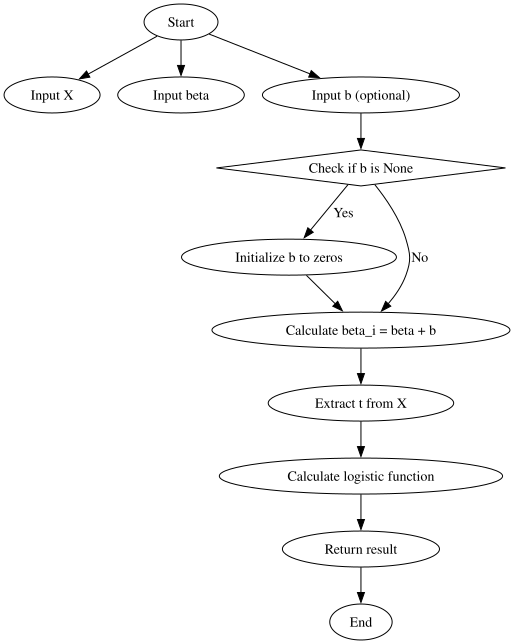

In [5]:
# Código do diagrama
dot = graphviz.Digraph(comment='Logistic Function Flow')
dot.node('START', 'Start', shape='oval')
dot.node('INPUT_X', 'Input X')
dot.node('INPUT_BETA', 'Input beta')
dot.node('INPUT_B', 'Input b (optional)')
dot.node('CHECK_B', 'Check if b is None', shape='diamond')
dot.node('INIT_B', 'Initialize b to zeros')
dot.node('CALCULATE_BETA_I', 'Calculate beta_i = beta + b')
dot.node('EXTRACT_T', 'Extract t from X')
dot.node('CALCULATE_LOGISTIC', 'Calculate logistic function')
dot.node('RETURN_RESULT', 'Return result')
dot.node('END', 'End', shape='oval')

dot.edge('START', 'INPUT_X')
dot.edge('START', 'INPUT_BETA')
dot.edge('START', 'INPUT_B')
dot.edge('INPUT_B', 'CHECK_B')
dot.edge('CHECK_B', 'INIT_B', label='Yes')
dot.edge('CHECK_B', 'CALCULATE_BETA_I', label='No')
dot.edge('INIT_B', 'CALCULATE_BETA_I')
dot.edge('CALCULATE_BETA_I', 'EXTRACT_T')
dot.edge('EXTRACT_T', 'CALCULATE_LOGISTIC')
dot.edge('CALCULATE_LOGISTIC', 'RETURN_RESULT')
dot.edge('RETURN_RESULT', 'END')

# Mostrar diagrama
dot

In [6]:

def logistic_grad(X, beta, b=None, with_respect_to='beta'):
    """Gradiente da função logística"""
    # [Implementação]

# Carregar dados

In [8]:
data = pd.read_csv('/home/huguinho/Documents/GitHub/robust_nlme_analysis/data/soybean_growth.csv')
data.head()

,Plot,Variety,Year,Time,weight
0,1988F1,F,1988,14,0.106
1,1988F1,F,1988,21,0.261
2,1988F1,F,1988,28,0.666
3,1988F1,F,1988,35,2.110
4,1988F1,F,1988,42,3.560


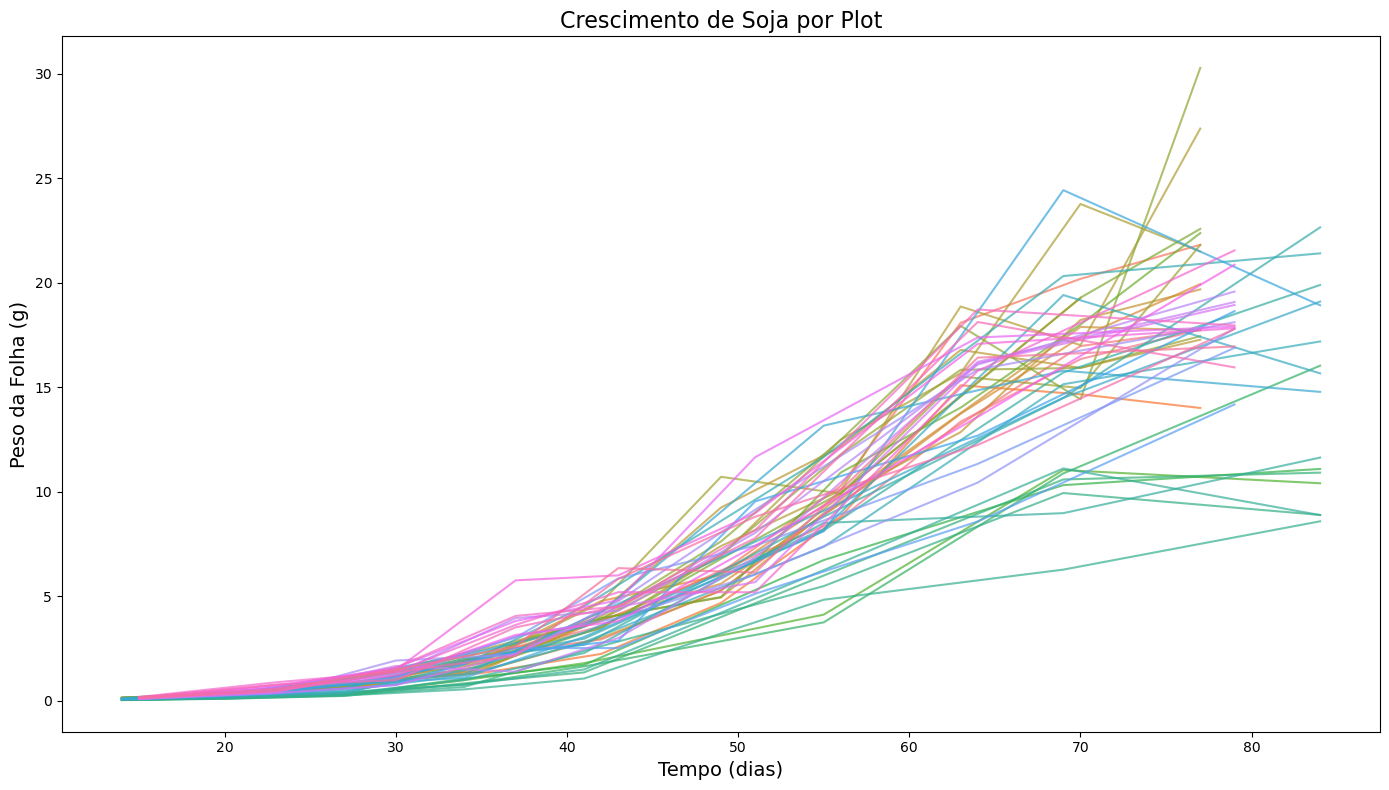

In [11]:
# Visualização exploratória
plt.figure(figsize=(14, 8))
sns.lineplot(data=data, x='Time', y='weight', hue='Plot', alpha=0.7, legend=False)
plt.title('Crescimento de Soja por Plot', fontsize=16)
plt.xlabel('Tempo (dias)', fontsize=14)
plt.ylabel('Peso da Folha (g)', fontsize=14)
plt.tight_layout()
plt.show()

In [14]:

# Ajustar modelo normal
results_normal = approximate_nlme(
    data=data,
    group_col="Plot", 
    nl_func=logistic,
    nl_grad=logistic_grad,
    y_col="weight",
    x_cols=["time"],
    initial_fixed=[19.0, 55.0, 9.0],
    initial_random_var=[16.0, 6.0, 0.1],
    initial_error_var=1.0,
    distribution="normal",
    max_iter=100,
    tol=1e-4
)

# [Continuar com ajuste de modelos robustos, análise de outliers, etc.]


Iniciando otimização pelo método aproximado...


  0%|          | 0/100 [00:00<?, ?it/s]


KeyError: "None of [Index(['time'], dtype='object')] are in the [columns]"